In [1]:
# 0) Imports + paths
# ==========================================
import re
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd

import nibabel as nib
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn import plotting
from nilearn.image import math_img

In [2]:
# 0) Imports + paths
# ==========================================
import re
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd

import nibabel as nib
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn import plotting
from nilearn.image import math_img

In [3]:
# 1) CONFIG
from pathlib import Path

TR = 0.8

SUBDIR = Path("/Volumes/T7 Shield/Data_project_CCD/latest_derivatives/sub-03")
FUNC = SUBDIR / "func"
OUTDIR = SUBDIR / "glm_notebookstyle_6conds_x_hand"
OUTDIR.mkdir(parents=True, exist_ok=True)

CSV_BY_TASK = {
    "MDOD": SUBDIR / "sub-03_task_MDOD_events.csv",
    "MDOG": SUBDIR / "sub-03_task_MDOG_events.csv",
    "MGOD": SUBDIR / "sub-03_task_MGOD_events.csv",
    "MGOG": SUBDIR / "sub-03_task_MGOG_events.csv",
}

CODE_TO_LABEL = {
    1:  "left_sight_alone",
    2:  "right_sight_alone",
    10: "left_ear_alone",
    20: "right_ear_alone",
    11: "left_audio_visual",
    22: "right_audio_visual",
}

CONFOUND_COLS = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z",
    "trans_x_derivative1", "trans_y_derivative1", "trans_z_derivative1",
    "rot_x_derivative1", "rot_y_derivative1", "rot_z_derivative1",
    "framewise_displacement", "csf", "white_matter",
]

In [4]:
# 2) Helpers
import re
import pandas as pd

def parse_task_run_space(fname):
    task_match = re.search(r"_task-([A-Za-z0-9]+)_", fname)
    run_match = re.search(r"_run-([0-9]+)_", fname)
    space_match = re.search(r"_space-([A-Za-z0-9_]+)_", fname)

    task = task_match.group(1) if task_match else None
    run = int(run_match.group(1)) if run_match else 0
    space = space_match.group(1) if space_match else "NA"

    return task, run, space


def choose_latest_runs_per_task_space(bolds):
    latest = {}
    for bold in bolds:
        task, run, space = parse_task_run_space(bold.name)
        key = (task, space)
        if key not in latest or run > latest[key][0]:
            latest[key] = (run, bold)
    return [latest[k][1] for k in sorted(latest)]


def find_confounds_for_bold(bold_path):
    task, run, _ = parse_task_run_space(bold_path.name)

    candidates = sorted(FUNC.glob(f"*task-{task}*confounds*.tsv"))

    if run != 0:
        run_candidates = [p for p in candidates if f"_run-{run}_" in p.name]
        if len(run_candidates) > 0:
            candidates = run_candidates

    if len(candidates) == 0:
        raise FileNotFoundError(f"No confounds found for {bold_path.name}")

    return candidates[0]


def read_confounds(path):
    for enc in ["utf-8", "latin1", "ISO-8859-1"]:
        try:
            return pd.read_csv(path, sep="\t", encoding=enc)
        except UnicodeDecodeError:
            pass
    return pd.read_csv(path, sep="\t", errors="ignore")

In [5]:
# 3) Event helpers
from io import StringIO

def _normalize_code(x):
    if pd.isna(x):
        return None
    try:
        return int(float(x))
    except:
        return None


def find_code_column(df):
    for col in df.columns:
        vals = set(_normalize_code(v) for v in df[col].dropna().unique())
        vals.discard(None)
        if len(vals & set(CODE_TO_LABEL.keys())) > 0:
            return col
    raise ValueError("No trigger/code column found")


from io import StringIO

from io import StringIO

def build_events_for_task(task):
    csv_path = CSV_BY_TASK[task]

    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln for ln in f if ln.strip()]

    header_idx = next(i for i, ln in enumerate(lines) if ln.lower().startswith("onset"))
    df = pd.read_csv(StringIO("".join(lines[header_idx:])))

    # keep only needed columns
    df = df[["onset", "duration", "trigger"]].copy()

    # numeric conversion
    df["onset"] = pd.to_numeric(df["onset"], errors="coerce")
    df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
    df["trigger"] = (
        df["trigger"]
        .astype(str)
        .str.strip()
        .replace("", np.nan)
    )
    df["trigger"] = pd.to_numeric(df["trigger"], errors="coerce")

    # drop bad rows
    df = df.dropna(subset=["onset", "duration", "trigger"]).copy()
    df["trigger"] = df["trigger"].astype(int)

    # keep only valid codes
    df = df[df["trigger"].isin(CODE_TO_LABEL.keys())].copy()

    # map labels
    df["trial_type"] = df["trigger"].map(CODE_TO_LABEL)

    return df[["onset", "duration", "trial_type"]].sort_values("onset").reset_index(drop=True)

In [8]:
TEST_TASK = "MDOG"

example_bold = next(
    (b for b in bolds if parse_task_run_space(b.name)[0] == TEST_TASK),
    None
)

if example_bold is None:
    raise RuntimeError(f"No run found for task {TEST_TASK}")

task_ex, run_ex, space_ex = parse_task_run_space(example_bold.name)
events_ex = build_events_for_task(task_ex)

print(events_ex["trial_type"].value_counts())
display(events_ex.head(20))

img_ex = nib.load(str(example_bold))
frame_times_ex = np.arange(img_ex.shape[-1]) * TR

design_ex = make_first_level_design_matrix(
    frame_times=frame_times_ex,
    events=events_ex,
    hrf_model="glover",
    drift_model="cosine",
    high_pass=1/128
)

for col in design_ex.columns:
    print(repr(col))

trial_type
left_audio_visual    10
left_ear_alone       10
right_sight_alone     5
left_sight_alone      5
Name: count, dtype: int64


,onset,duration,trial_type
0,5.584591,0.574610,right_sight_alone
1,7.620522,0.584171,left_sight_alone
2,10.154156,0.600554,left_sight_alone
3,14.690652,0.577856,left_audio_visual
4,18.240376,0.509107,left_sight_alone
5,20.282713,0.648249,left_ear_alone
6,24.318966,0.430060,left_audio_visual
7,26.854838,0.537013,left_ear_alone
8,29.391645,0.389302,left_audio_visual
9,33.927352,0.508219,left_sight_alone


'left_audio_visual'
'left_ear_alone'
'left_sight_alone'
'right_sight_alone'
'drift_1'
'constant'


In [7]:
# 4) Find BOLD runs and keep the latest run for each task/space
bolds_all = sorted(FUNC.glob("*desc-preproc_bold.nii.gz"))
if len(bolds_all) == 0:
    raise FileNotFoundError(f"No BOLD files found in {FUNC}")

bolds_t1w = [b for b in bolds_all if "_space-T1w_" in b.name]
bolds_use = bolds_t1w if len(bolds_t1w) > 0 else bolds_all

bolds = choose_latest_runs_per_task_space(bolds_use)

for b in bolds:
    print(b.name)

sub-03_task-MDOD_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz
sub-03_task-MDOG_run-2_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz
sub-03_task-MGOD_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz
sub-03_task-MGOG_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz
sub-03_task-rest_space-MNIPediatricAsym_cohort-3_res-1_desc-preproc_bold.nii.gz


In [9]:
# 5) Quick check: number of volumes and duration
run_info = []

for b in bolds:
    task, run, space = parse_task_run_space(b.name)
    img = nib.load(str(b))
    n_vol = img.shape[-1]
    duration_s = n_vol * TR

    run_info.append([task, run, space, n_vol, duration_s])

run_info_df = pd.DataFrame(
    run_info,
    columns=["task", "run", "space", "n_vol", "duration_s"]
)

run_info_df

,task,run,space,n_vol,duration_s
0,MDOD,0,MNIPediatricAsym,154,123.2
1,MDOG,2,MNIPediatricAsym,141,112.8
2,MGOD,0,MNIPediatricAsym,146,116.8
3,MGOG,0,MNIPediatricAsym,141,112.8
4,rest,0,MNIPediatricAsym,600,480.0


trial_type
left_audio_visual    10
left_ear_alone       10
right_sight_alone     5
left_sight_alone      5
Name: count, dtype: int64
['left_audio_visual', 'left_ear_alone', 'left_sight_alone', 'right_sight_alone', 'drift_1', 'constant']


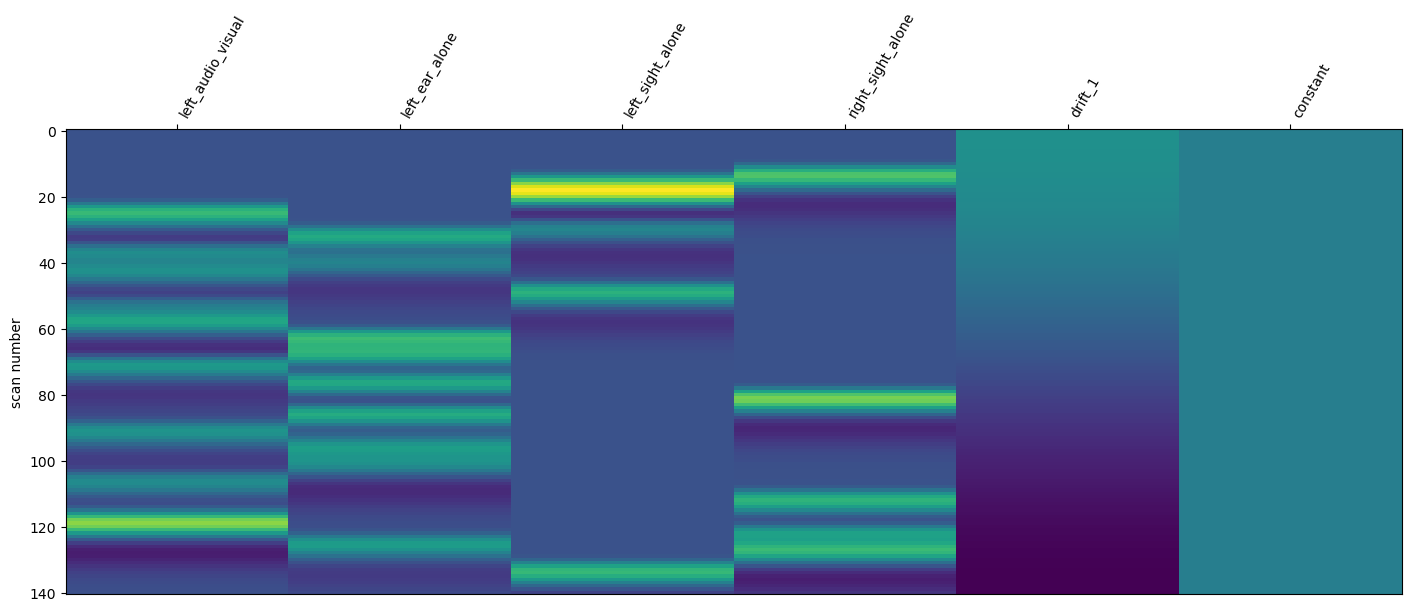

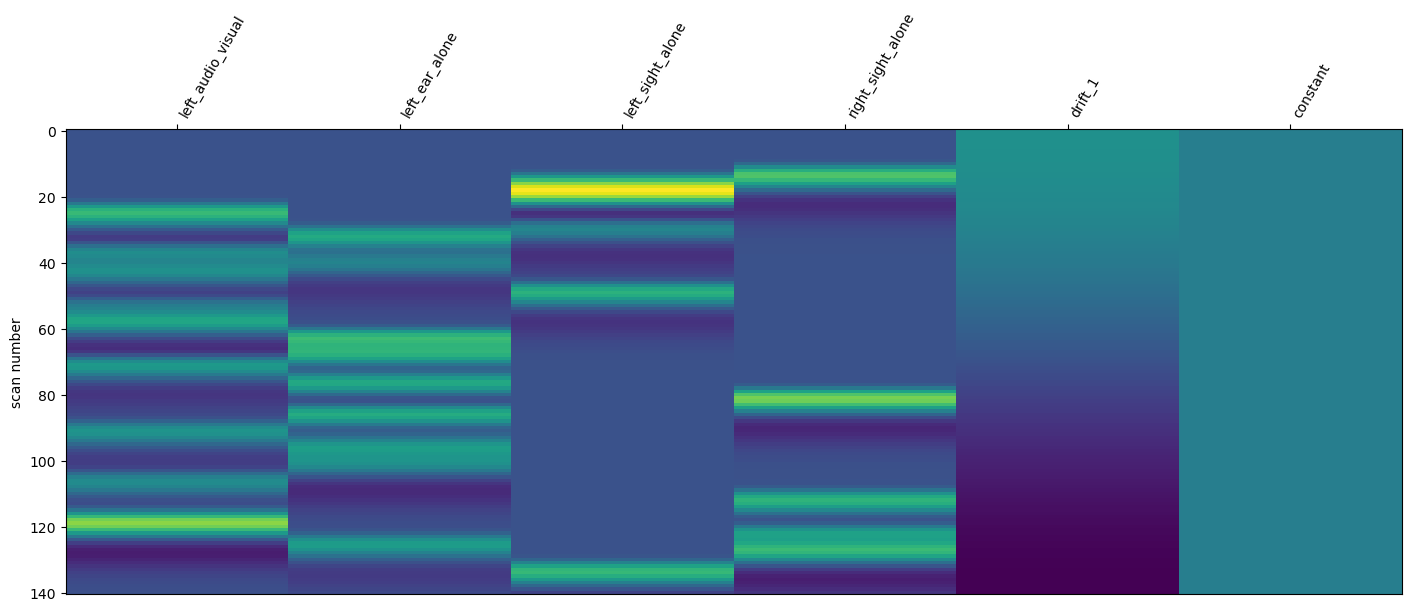

In [10]:
# 6) Build events + design matrix preview for one run

TEST_TASK = "MDOG"

example_bold = next(
    (b for b in bolds if parse_task_run_space(b.name)[0] == TEST_TASK),
    None
)

if example_bold is None:
    raise RuntimeError(f"No run found for task {TEST_TASK}")

task_ex, run_ex, space_ex = parse_task_run_space(example_bold.name)
events_ex = build_events_for_task(task_ex)

print(events_ex["trial_type"].value_counts())

img_ex = nib.load(str(example_bold))
frame_times_ex = np.arange(img_ex.shape[-1]) * TR

design_ex = make_first_level_design_matrix(
    frame_times_ex,
    events_ex,
    hrf_model="glover",
    drift_model="cosine",
    high_pass=1/128
)

print(list(design_ex.columns))

ax = plotting.plot_design_matrix(design_ex)
ax.figure.set_size_inches(14, 6)
ax.figure

In [10]:
# 7) Crossed > Uncrossed contrast

def crossed_gt_uncrossed_contrast(design, task):
    c = np.zeros(len(design.columns))

    if task == "MDOG":
        crossed = {"left_sight_alone", "left_ear_alone", "left_audio_visual"}
        uncrossed = {"right_sight_alone"}

    elif task == "MGOD":
        crossed = {"right_sight_alone", "right_ear_alone", "right_audio_visual"}
        uncrossed = {"left_sight_alone"}

    elif task == "MDOD":
        crossed = {"left_sight_alone", "right_ear_alone", "right_audio_visual"}
        uncrossed = {"right_sight_alone"}

    elif task == "MGOG":
        crossed = {"right_sight_alone", "left_ear_alone", "left_audio_visual"}
        uncrossed = {"left_sight_alone"}

    else:
        raise ValueError(f"Unknown task: {task}")

    for i, col in enumerate(design.columns):
        if col in crossed:
            c[i] = 1.0
        elif col in uncrossed:
            c[i] = -1.0

    return c

In [11]:
print("task_ex =", task_ex)
print("design columns =", list(design_ex.columns))

contrast = crossed_gt_uncrossed_contrast(design_ex, task_ex)

for name, val in zip(design_ex.columns, contrast):
    if val != 0:
        print(name, val)

task_ex = MDOG
design columns = ['left_audio_visual', 'left_ear_alone', 'left_sight_alone', 'right_sight_alone', 'drift_1', 'constant']
left_audio_visual 1.0
left_ear_alone 1.0
left_sight_alone 1.0
right_sight_alone -1.0


In [ ]:
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask

TEST_TASK = "MDOG"

bold = next((b for b in bolds if parse_task_run_space(b.name)[0] == TEST_TASK), None)
if bold is None:
    raise RuntimeError(f"No run found for task {TEST_TASK}")

task, run, space = parse_task_run_space(bold.name)

events = build_events_for_task(task)

img = nib.load(str(bold))
n_scans = img.shape[-1]

conf = read_confounds(find_confounds_for_bold(bold))
conf = conf[[c for c in CONFOUND_COLS if c in conf.columns]].fillna(0)

if len(conf) > n_scans:
    conf = conf.iloc[:n_scans].copy()
elif len(conf) < n_scans:
    conf = conf.reindex(range(n_scans)).fillna(0)

mask_img = compute_epi_mask(str(bold))

glm = FirstLevelModel(
    t_r=TR,
    mask_img=mask_img,
    hrf_model="glover",
    drift_model="cosine",
    high_pass=1/128,
    noise_model="ols",
    smoothing_fwhm=None,
    minimize_memory=True
)

glm = glm.fit(str(bold), events=events, confounds=conf)

contrast = crossed_gt_uncrossed_contrast(glm.design_matrices_[0], task)
zmap = glm.compute_contrast(contrast, output_type="z_score")

out_file = OUTDIR / f"sub-03_task-{task}_run-{run}_fast_zmap.nii.gz"
zmap.to_filename(str(out_file))

print("saved:", out_file.name)

/var/folders/3b/qt6wbv8n03726nsjmp6_gz1h0000gn/T/ipykernel_1974/2660787474.py:38: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  glm = glm.fit(str(bold), events=events, confounds=conf)


In [ ]:
#too long
from nilearn.glm.first_level import FirstLevelModel

zmaps = []

for bold in bolds:
    task, run, space = parse_task_run_space(bold.name)

    if task not in CSV_BY_TASK:
        continue

    events = build_events_for_task(task)

    img = nib.load(str(bold))
    n_scans = img.shape[-1]

    conf = read_confounds(find_confounds_for_bold(bold))
    conf = conf[[c for c in CONFOUND_COLS if c in conf.columns]].fillna(0)

    # make confounds match the number of scans
    if len(conf) > n_scans:
        conf = conf.iloc[:n_scans].copy()
    elif len(conf) < n_scans:
        conf = conf.reindex(range(n_scans)).fillna(0)

    print(f"{task} run {run}: n_scans={n_scans}, conf_rows={len(conf)}")


    glm = FirstLevelModel(
    t_r=TR,
    hrf_model="glover",
    drift_model="cosine",
    high_pass=1/128,
    noise_model="ols",
    smoothing_fwhm=None,
    mask_img=None,  # nilearn auto-mask
    minimize_memory=True
    ).fit(str(bold), events=events, confounds=conf)

    contrast = crossed_gt_uncrossed_contrast(glm.design_matrices_[0], task)
    zmap = glm.compute_contrast(contrast, output_type="z_score")

    out_file = OUTDIR / f"sub-03_task-{task}_run-{run}_zmap.nii.gz"
    zmap.to_filename(str(out_file))

    print("saved:", out_file.name)
    zmaps.append(zmap)

MDOD run 0: n_scans=154, conf_rows=154


In [ ]:
# 9) Mean z-map across runs (simple summary)
# ==========================================
if len(zmaps) == 0:
    raise RuntimeError("No z-maps computed. Check your runs/events.")

if len(zmaps) == 1:
    zmean = zmaps[0]
else:
    expr = "(" + " + ".join([f"img{i}" for i in range(len(zmaps))]) + f") / {len(zmaps)}"
    zmean = math_img(expr, **{f"img{i}": zmaps[i] for i in range(len(zmaps))})

zmean_file = OUTDIR / "sub-03_zmap_MEAN_crossed_gt_uncrossed.nii.gz"
zmean.to_filename(str(zmean_file))
print("[OK] saved mean z:", zmean_file)